In [4]:
import os as os
import sys

# adding folders to sys.path
project_root = os.path.abspath(os.path.join(os.getcwd()  , '..', '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

akshat_lisa_root = os.path.abspath(os.path.join(os.getcwd()  , '..',))
if akshat_lisa_root not in sys.path:
    sys.path.insert(0, akshat_lisa_root)

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from bbhx.utils.constants import *
from bbhx.utils.transform import *
from scripts.lisa_mbbh_strain import lisa_mbbh_strain
from scripts.readTdi import getTdiPath, readTdi
from scripts.wosa import wosa
from scripts.plot import plot
np.random.seed(111222)

In [5]:
0.5 * YRSID_SI

15779074.881772801

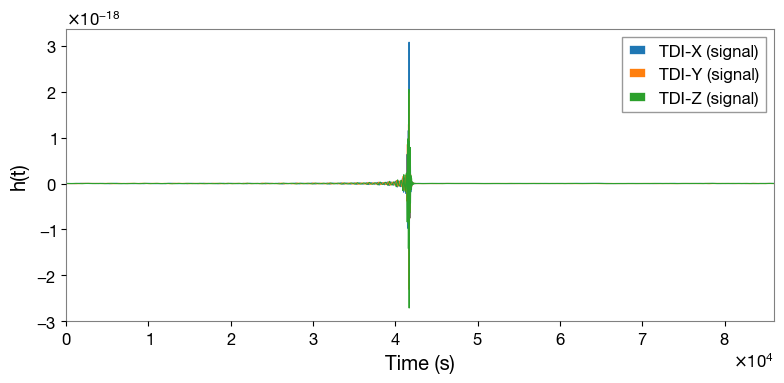

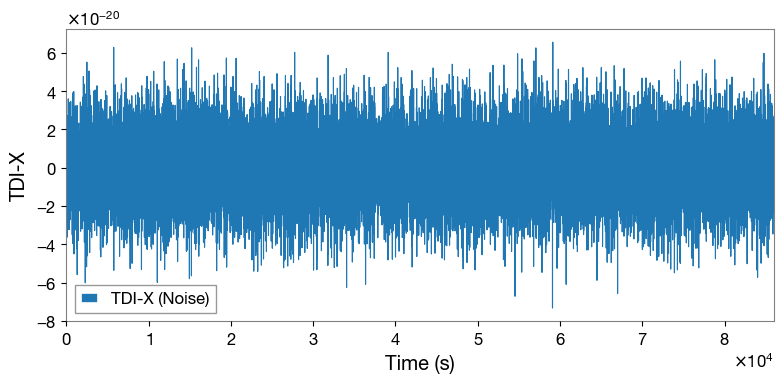

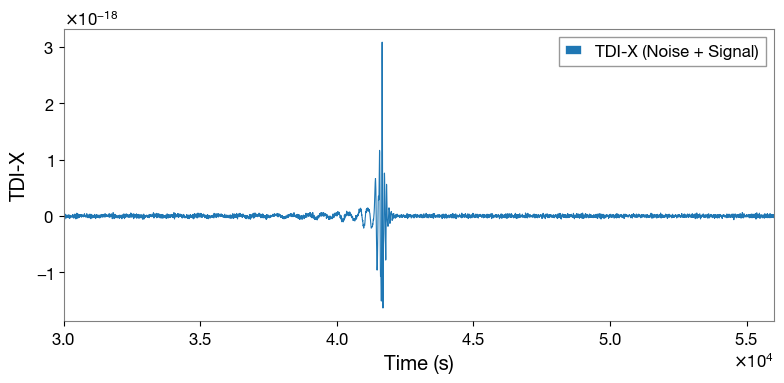

In [6]:
# Generate and plot signal
t_mbbh, hX, hY, hZ = lisa_mbbh_strain(
    m1=1e6, m2=5e5,
    a1=0.2, a2=0.4,
    dist=18e3 * PC_SI * 1e6,
    phi_ref=0.0,
    f_ref=0.0,
    inc=np.pi/3,
    lam=np.pi/5,
    beta=np.pi/4,
    psi=np.pi/6,
    N=17200,
    t_ref=0.5 * YRSID_SI,
    dt=5.0
)

plt.figure(figsize=(8,4))
plt.plot(t_mbbh, hX, lw=0.8, label='TDI-X (signal)')
plt.plot(t_mbbh, hY, lw=0.8, label='TDI-Y (signal)')
plt.plot(t_mbbh, hZ, lw=0.8, label='TDI-Z (signal)')
plt.xlabel('Time (s)')
plt.ylabel('h(t)')
plt.xlim(t_mbbh[0], t_mbbh[-1])
# plt.xlim(35000, 44000)
plt.grid(False)
plt.legend(); plt.tight_layout(); plt.show()


# Generate and plot noise
tdi_path = getTdiPath('glitch_1.h5')
tdi_noise, fs, t = readTdi(tdi_path)

plt.figure(figsize=(8,4))
plt.plot(t, tdi_noise, lw=0.8, label='TDI-X (Noise)')
plt.xlabel('Time (s)')
plt.ylabel('TDI-X')
plt.xlim(t[0], t[-1])
plt.grid(False)
plt.legend(); plt.tight_layout(); plt.show()


# plot noise + signal
signal_and_noise = tdi_noise+hX
plt.figure(figsize=(8,4))
plt.plot(t, signal_and_noise, lw=0.8, label='TDI-X (Noise + Signal)')
plt.xlabel('Time (s)')
plt.ylabel('TDI-X')
plt.xlim(t[0], t[-1])
plt.grid(False)
plt.xlim(30000, 56000)
plt.legend(); plt.tight_layout(); plt.show()
# "location of constellation" should be same for tdi-noise and signal

/Users/akmdgreat/anaconda3/envs/bethenv/lib/python3.11/site-packages/gwpy/plot/axes.py:78: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  return func(self, **kw)


16


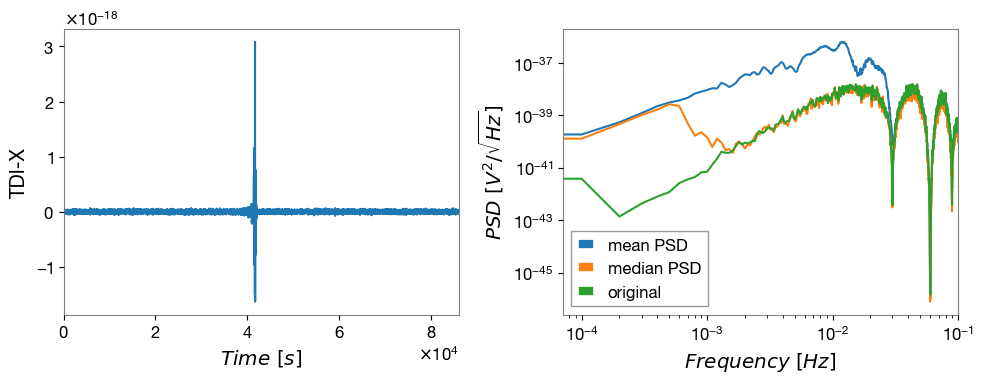

In [7]:
nperseg = 2000

tdi_path = getTdiPath('glitch_1.h5')
data_orig, fs, t = readTdi(tdi_path)
f_orig, psd_orig, _, nseg = wosa(
    x=data_orig,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 

f_mean, psd_mean, _, nseg = wosa(
    x=signal_and_noise,
    fs=fs,
    nperseg=nperseg,
    method="mean"
)

# compute median‐PSD
f_median, psd_median, _, _ = wosa(
    x=signal_and_noise,
    fs=fs,
    nperseg=nperseg,
    method="median"
)

# plot all three curves (assuming psd_orig is defined)
plot(
    data=signal_and_noise,
    t=t,
    f=f_mean,
    psd=[psd_mean, psd_median, psd_orig],
    labels=["mean PSD", "median PSD", "original"],
    title=f"TDI-X",
    f_lims=[f_mean[0], f_mean[-1]]
)

# 1 signal to a longer data 
# larger and smaller amplitude for the mbbh signal 
print(nseg[0])

(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: xlabel='$Time \\ [s]$', ylabel='TDI-X'>,
        <Axes: xlabel='$Frequency \\ [Hz]$', ylabel='$PSD \\ [V^2/\\sqrt{Hz}]$'>],
       dtype=object))

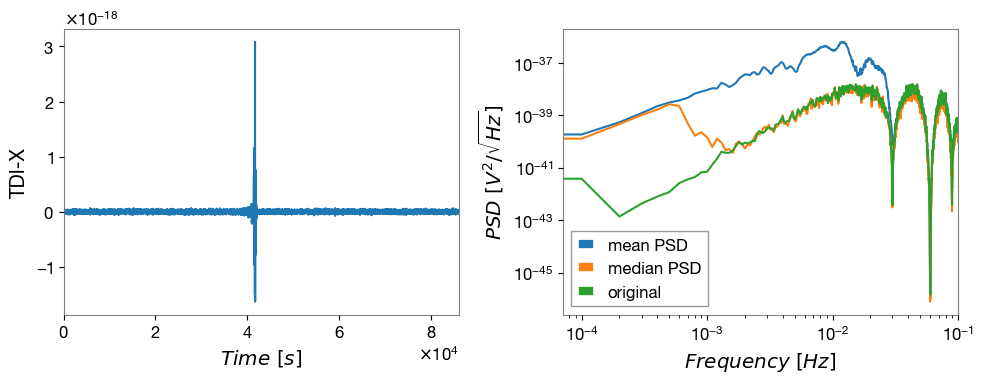

In [8]:
# Generate and plot signal
t_mbbh, hX, hY, hZ = lisa_mbbh_strain(
    m1=1e6, m2=5e5,
    a1=0.2, a2=0.4,
    dist=18e3 * PC_SI * 1e6,
    phi_ref=0.0,
    f_ref=0.0,
    inc=np.pi/3,
    lam=np.pi/5,
    beta=np.pi/4,
    psi=np.pi/6,
    N=17200,
    t_ref=0.5 * YRSID_SI,
    dt=5.0
)
tdi_path = getTdiPath('glitch_1.h5')
tdi_noise, fs, t = readTdi(tdi_path)
signal_and_noise = tdi_noise+hX

nperseg = 2000
tdi_path = getTdiPath('glitch_1.h5')
data_orig, fs, t = readTdi(tdi_path)
f_orig, psd_orig, _, _ = wosa(
    x=data_orig,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 

f_mean, psd_mean, _, nseg = wosa(
    x=signal_and_noise,
    fs=fs,
    nperseg=nperseg,
    method="mean"
)

# compute median‐PSD
f_median, psd_median, _, _ = wosa(
    x=signal_and_noise,
    fs=fs,
    nperseg=nperseg,
    method="median"
)

# plot all three curves (assuming psd_orig is defined)
plot(
    data=signal_and_noise,
    t=t,
    f=f_mean,
    psd=[psd_mean, psd_median, psd_orig],
    labels=["mean PSD", "median PSD", "original"],
    title=f"TDI-X",
    f_lims=[f_mean[0], f_mean[-1]]
)

# 1 signal to a longer data 
# larger and smaller amplitude for the mbbh signal 

(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: xlabel='$Time \\ [s]$', ylabel='TDI-X'>,
        <Axes: xlabel='$Frequency \\ [Hz]$', ylabel='$PSD \\ [V^2/\\sqrt{Hz}]$'>],
       dtype=object))

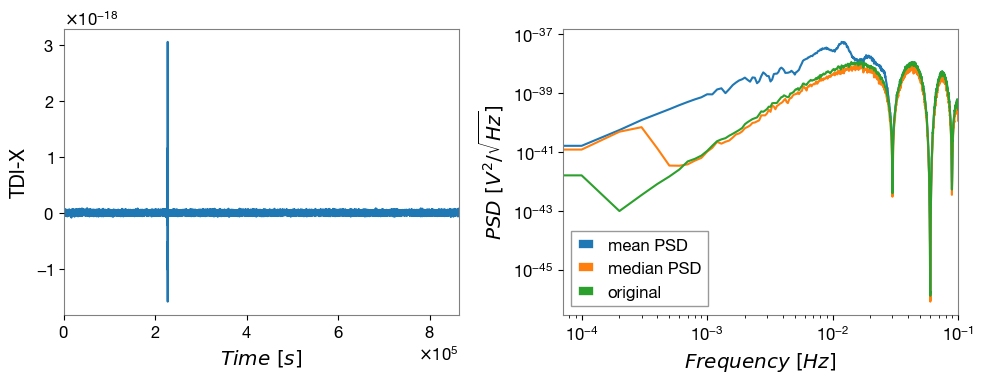

In [10]:
# Generate and plot signal
t_mbbh, hX, hY, hZ = lisa_mbbh_strain(
    m1=1e6, m2=5e5,
    a1=0.2, a2=0.4,
    dist=18e3 * PC_SI * 1e6,
    phi_ref=0.0,
    f_ref=0.0,
    inc=np.pi/3,
    lam=np.pi/5,
    beta=np.pi/4,
    psi=np.pi/6,
    N=172800,
    t_ref=0.5 * YRSID_SI,
    dt=5.0
)
tdi_path = getTdiPath('glitch_1_10_days.h5')
tdi_noise, fs, t = readTdi(tdi_path)
signal_and_noise = tdi_noise+hX

nperseg = 2000
tdi_path = getTdiPath('glitch_1_10_days.h5')
data_orig, fs, t = readTdi(tdi_path)
f_orig, psd_orig, _, _ = wosa(
    x=data_orig,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 

f_mean, psd_mean, _, nseg = wosa(
    x=signal_and_noise,
    fs=fs,
    nperseg=nperseg,
    method="mean"
)

# compute median‐PSD
f_median, psd_median, _, _ = wosa(
    x=signal_and_noise,
    fs=fs,
    nperseg=nperseg,
    method="median"
)

# plot all three curves (assuming psd_orig is defined)
plot(
    data=signal_and_noise,
    t=t,
    f=f_mean,
    psd=[psd_mean, psd_median, psd_orig],
    labels=["mean PSD", "median PSD", "original"],
    title=f"TDI-X",
    f_lims=[f_mean[0], f_mean[-1]]
)

# 1 signal to a longer data 
# larger and smaller amplitude for the mbbh signal 

(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: xlabel='$Time \\ [s]$', ylabel='TDI-X'>,
        <Axes: xlabel='$Frequency \\ [Hz]$', ylabel='$PSD \\ [V^2/\\sqrt{Hz}]$'>],
       dtype=object))

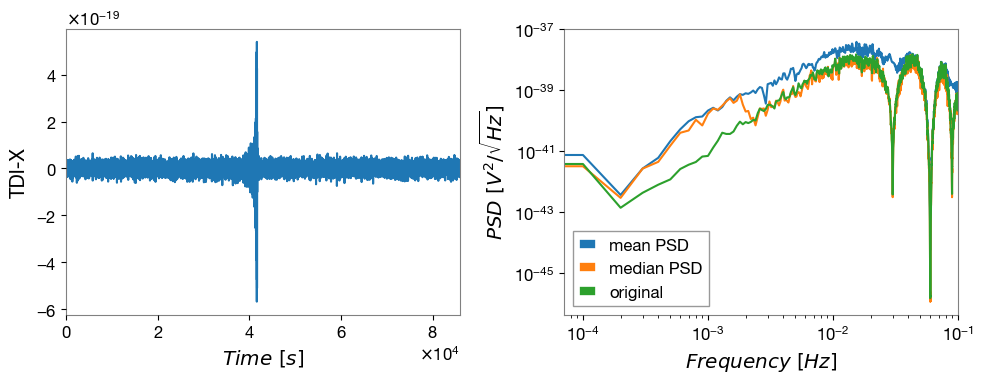

In [11]:
t_mbbh, hX, hY, hZ = lisa_mbbh_strain(
    m1=1e5, m2=5e4,
    a1=0.2, a2=0.4,
    dist=18e3 * PC_SI * 1e6,
    phi_ref=0.0,
    f_ref=0.0,
    inc=np.pi/3,
    lam=np.pi/5,
    beta=np.pi/4,
    psi=np.pi/6,
    N=17200,
    t_ref=0.5 * YRSID_SI,
    dt=5.0
)

tdi_path = getTdiPath('glitch_1.h5')
tdi_noise, fs, t = readTdi(tdi_path)
signal_and_noise = tdi_noise+hX

nperseg = 2000
tdi_path = getTdiPath('glitch_1.h5')
data_orig, fs, t = readTdi(tdi_path)
f_orig, psd_orig, _, _ = wosa(
    x=data_orig,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 

f_mean, psd_mean, _, nseg = wosa(
    x=signal_and_noise,
    fs=fs,
    nperseg=nperseg,
    method="mean"
)

# compute median‐PSD
f_median, psd_median, _, _ = wosa(
    x=signal_and_noise,
    fs=fs,
    nperseg=nperseg,
    method="median"
)

# plot all three curves (assuming psd_orig is defined)
plot(
    data=signal_and_noise,
    t=t,
    f=f_mean,
    psd=[psd_mean, psd_median, psd_orig],
    labels=["mean PSD", "median PSD", "original"],
    title=f"TDI-X",
    f_lims=[f_mean[0], f_mean[-1]]
)

# shifting injection to left

(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: xlabel='$Time \\ [s]$', ylabel='TDI-X'>,
        <Axes: xlabel='$Frequency \\ [Hz]$', ylabel='$PSD \\ [V^2/\\sqrt{Hz}]$'>],
       dtype=object))

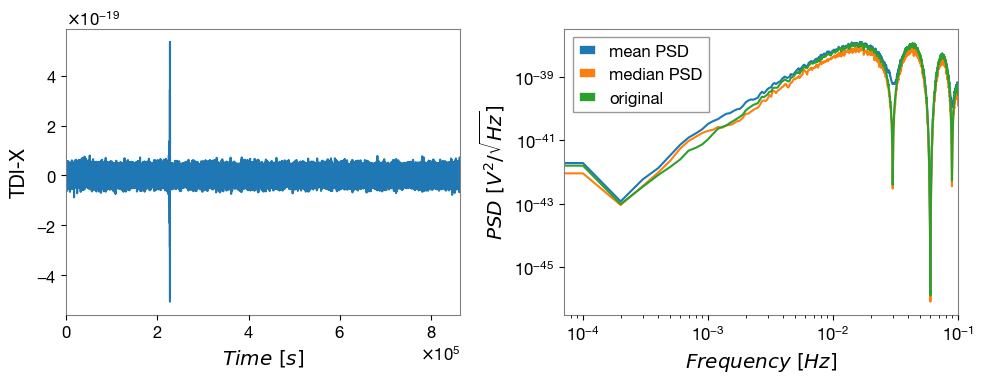

In [12]:
t_mbbh, hX, hY, hZ = lisa_mbbh_strain(
    m1=1e5, m2=5e4,
    a1=0.2, a2=0.4,
    dist=18e3 * PC_SI * 1e6,
    phi_ref=0.0,
    f_ref=0.0,
    inc=np.pi/3,
    lam=np.pi/5,
    beta=np.pi/4,
    psi=np.pi/6,
    N=172800,
    t_ref=0.5 * YRSID_SI,
    dt=5.0
)

tdi_path = getTdiPath('glitch_1_10_days.h5')
tdi_noise, fs, t = readTdi(tdi_path)
signal_and_noise = tdi_noise+hX

nperseg = 2000
tdi_path = getTdiPath('glitch_1_10_days.h5')
data_orig, fs, t = readTdi(tdi_path)
f_orig, psd_orig, _, _ = wosa(
    x=data_orig,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 

f_mean, psd_mean, _, nseg = wosa(
    x=signal_and_noise,
    fs=fs,
    nperseg=nperseg,
    method="mean"
)

# compute median‐PSD
f_median, psd_median, _, _ = wosa(
    x=signal_and_noise,
    fs=fs,
    nperseg=nperseg,
    method="median"
)

# plot all three curves (assuming psd_orig is defined)
plot(
    data=signal_and_noise,
    t=t,
    f=f_mean,
    psd=[psd_mean, psd_median, psd_orig],
    labels=["mean PSD", "median PSD", "original"],
    title=f"TDI-X",
    f_lims=[f_mean[0], f_mean[-1]]
)

(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: xlabel='$Time \\ [s]$', ylabel='TDI-X'>,
        <Axes: xlabel='$Frequency \\ [Hz]$', ylabel='$PSD \\ [V^2/\\sqrt{Hz}]$'>],
       dtype=object))

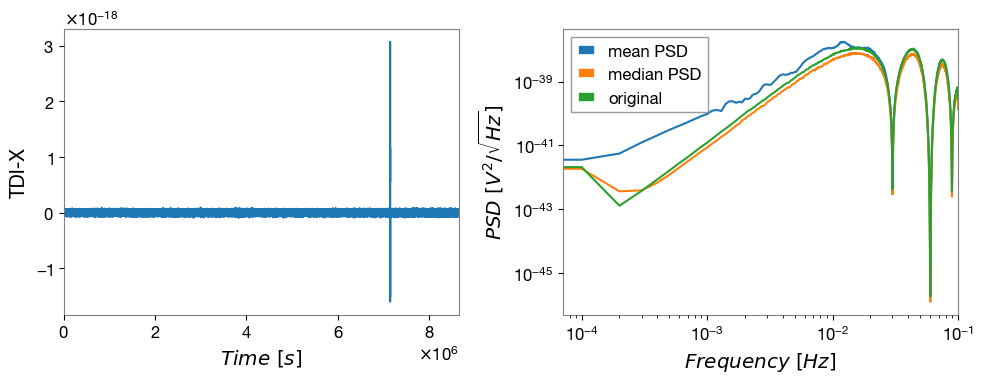

In [15]:
# Generate and plot signal
t_mbbh, hX, hY, hZ = lisa_mbbh_strain(
    m1=1e6, m2=5e5,
    a1=0.2, a2=0.4,
    dist=18e3 * PC_SI * 1e6,
    phi_ref=0.0,
    f_ref=0.0,
    inc=np.pi/3,
    lam=np.pi/5,
    beta=np.pi/4,
    psi=np.pi/6,
    N=1728000,
    t_ref=0.5 * YRSID_SI,
    dt=5.0
)
tdi_path = getTdiPath('glitch_1_100_days.h5')
tdi_noise, fs, t = readTdi(tdi_path)
signal_and_noise = tdi_noise+hX

nperseg = 2000
tdi_path = getTdiPath('glitch_1_100_days.h5')
data_orig, fs, t = readTdi(tdi_path)
f_orig, psd_orig, _, _ = wosa(
    x=data_orig,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 

f_mean, psd_mean, _, nseg = wosa(
    x=signal_and_noise,
    fs=fs,
    nperseg=nperseg,
    method="mean"
)

# compute median‐PSD
f_median, psd_median, _, _ = wosa(
    x=signal_and_noise,
    fs=fs,
    nperseg=nperseg,
    method="median"
)

# plot all three curves (assuming psd_orig is defined)
plot(
    data=signal_and_noise,
    t=t,
    f=f_mean,
    psd=[psd_mean, psd_median, psd_orig],
    labels=["mean PSD", "median PSD", "original"],
    title=f"TDI-X",
    f_lims=[f_mean[0], f_mean[-1]]
)

# 1 signal to a longer data 
# larger and smaller amplitude for the mbbh signal 

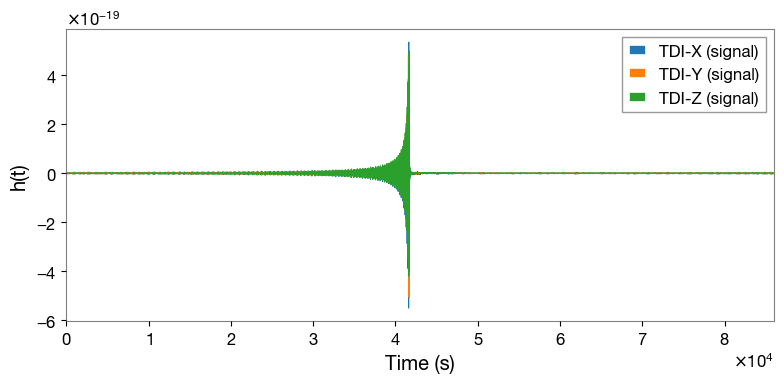

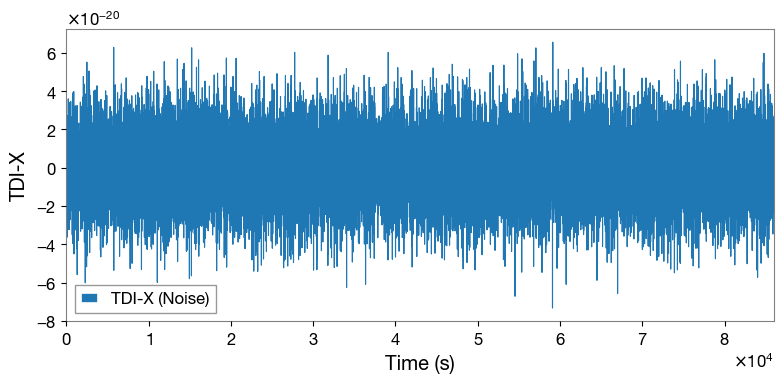

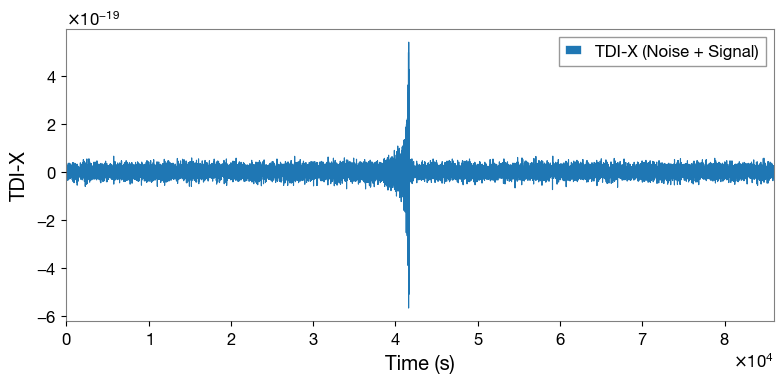

In [16]:
# Generate and plot signal
t_mbbh, hX, hY, hZ = lisa_mbbh_strain(
    m1=1e5, m2=5e4,
    a1=0.2, a2=0.4,
    dist=18e3 * PC_SI * 1e6,
    phi_ref=0.0,
    f_ref=0.0,
    inc=np.pi/3,
    lam=np.pi/5,
    beta=np.pi/4,
    psi=np.pi/6,
    N=17200,
    t_ref=0.5 * YRSID_SI,
    dt=5.0
)

plt.figure(figsize=(8,4))
plt.plot(t_mbbh, hX, lw=0.8, label='TDI-X (signal)')
plt.plot(t_mbbh, hY, lw=0.8, label='TDI-Y (signal)')
plt.plot(t_mbbh, hZ, lw=0.8, label='TDI-Z (signal)')
plt.xlabel('Time (s)')
plt.ylabel('h(t)')
plt.xlim(t_mbbh[0], t_mbbh[-1])
plt.grid(False)
plt.legend(); plt.tight_layout(); plt.show()


# Generate and plot noise
tdi_path = getTdiPath('glitch_1.h5')
tdi_noise, fs, t = readTdi(tdi_path)

plt.figure(figsize=(8,4))
plt.plot(t, tdi_noise, lw=0.8, label='TDI-X (Noise)')
plt.xlabel('Time (s)')
plt.ylabel('TDI-X')
plt.xlim(t[0], t[-1])
plt.grid(False)
plt.legend(); plt.tight_layout(); plt.show()


# plot noise + signal
signal_and_noise = tdi_noise+hX
plt.figure(figsize=(8,4))
plt.plot(t, signal_and_noise, lw=0.8, label='TDI-X (Noise + Signal)')
plt.xlabel('Time (s)')
plt.ylabel('TDI-X')
plt.xlim(t[0], t[-1])
plt.grid(False)
# plt.xlim(50000, 56000)
plt.legend(); plt.tight_layout(); plt.show()

(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: xlabel='$Time \\ [s]$', ylabel='TDI-X'>,
        <Axes: xlabel='$Frequency \\ [Hz]$', ylabel='$PSD \\ [V^2/\\sqrt{Hz}]$'>],
       dtype=object))

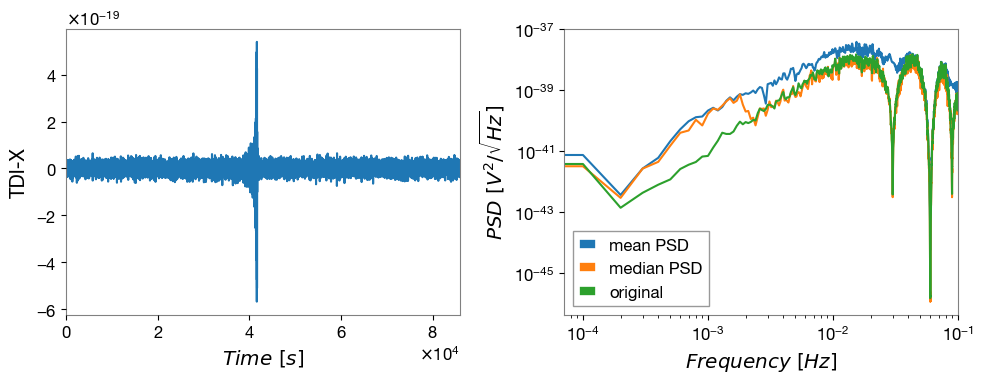

In [17]:
nperseg = 2000

tdi_path = getTdiPath('glitch_1.h5')
data_orig, fs, t = readTdi(tdi_path)
f_orig, psd_orig, _, _ = wosa(
    x=data_orig,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 

f_mean, psd_mean, _, nseg = wosa(
    x=signal_and_noise,
    fs=fs,
    nperseg=nperseg,
    method="mean"
)

# compute median‐PSD
f_median, psd_median, _, _ = wosa(
    x=signal_and_noise,
    fs=fs,
    nperseg=nperseg,
    method="median"
)

# plot all three curves (assuming psd_orig is defined)
plot(
    data=signal_and_noise,
    t=t,
    f=f_mean,
    psd=[psd_mean, psd_median, psd_orig],
    labels=["mean PSD", "median PSD", "original"],
    title=f"TDI-X",
    f_lims=[f_mean[0], f_mean[-1]]
)